**Import packages and dependecies**

In [1]:
%pip install -q -e ..

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from fda.basis import BSplineBasis

warnings.filterwarnings("ignore")

### 1. Plotting B-Splines Basis of Different Degrees

**Example 1:**

In [ ]:
# 1. Setup parameters
domain = (0, 15)
n_basis = 6
degree = 4

# 2. Initialize the basis class
basis = BSplineBasis(domain_range=domain, n_basis=n_basis, degree=degree)

# 3. Create evaluation points
x_array = np.linspace(domain[0], domain[1], 10)

# Show knot values
print("\nKnots:")
print("-"*100)
print(f"{basis.knots}")

# 4. Evaluate all basis functions
basis_matrix = basis.evaluate(x_array)
print("\nEvaluated basis values:")
print("-"*100)
print(f"{basis_matrix}")

# 5. Calculate derivatives
derivatives_order1 = basis.evaluate_derivative(eval_points=x_array, order=1)
derivatives_order2 = basis.evaluate_derivative(eval_points=x_array, order=2)

print("\nOrder 1 Derivatives:")
print("-"*100)
print(f"{derivatives_order1}")

print("\nOrder 2 Derivatives:")
print("-"*100)
print(f"{derivatives_order2}")


In [ ]:
# 5. Create a plot of the B-splines
basis.plot_b_spline(x_array)

**Example 2**

In [ ]:
# 1. Setup parameters
domain = (0, 15)
n_basis = 3
degree = 0

# 2. Initialize the basis class
basis = BSplineBasis(domain_range=domain, n_basis=n_basis, degree=degree)

# 3. Create evaluation points
x_array = np.linspace(domain[0], domain[1], 10)

# Show knot values
print("\nKnots:")
print("-"*100)
print(f"{basis.knots}")

# 4. Evaluate all basis functions
basis_matrix = basis.evaluate(x_array)
print("\nEvaluated basis values:")
print("-"*100)
print(f"{basis_matrix}")

# 5. Calculate derivatives
derivatives_order1 = basis.evaluate_derivative(eval_points=x_array, order=1)
derivatives_order2 = basis.evaluate_derivative(eval_points=x_array, order=2)

print("\nOrder 1 Derivatives:")
print("-"*100)
print(f"{derivatives_order1}")

print("\nOrder 2 Derivatives:")
print("-"*100)
print(f"{derivatives_order2}")

In [ ]:
# 5. Create a plot of the B-splines
basis.plot_b_spline(x_array)

### 2. Comparing Different Weighting Methods for B-Splines

In [ ]:
# 1. Setup parameters
domain = (0, 15)
n_basis = 4
degree = 3
weight_type_list = ["linear", "trigonometric", "hyperbolic", "variable_degree", "nurbs"]

# 2. Create evaluation points
x_array = np.linspace(domain[0], domain[1], 10)

# 3. Create a function p(x) to use for variable_degree weighting
def smooth_sigmoid_degree_func(x: np.ndarray) -> np.ndarray:
    """
    Uses a logistic curve to smoothly transition from degree 1.0 to 3.0,
    centered at x = 5.0 with a growth rate parameter.
    """
    center = 5.0
    growth_rate = 2.0  # Controls how steep the transition is
    p_min = 1.0
    p_max = 3.0
    
    # Standard logistic formula
    sigmoid = 1.0 / (1.0 + np.exp(-growth_rate * (x - center)))
    
    # Scale to the target degree range
    p_x = p_min + sigmoid * (p_max - p_min)
    return p_x

# 4. Create NURBS weight to apply
nurbs_weights = np.array([5.4, -4.5, 1.5, 1.2])

for weight_type in weight_type_list:

    print(f"\nWEIGHT TYPE: {weight_type.upper()}")
    print("-"*100)

    # 5. Initialize the basis class
    if weight_type == "variable_degree":
        p_func=smooth_sigmoid_degree_func
    else: 
        p_func=None
    basis = BSplineBasis(domain_range=domain, n_basis=n_basis, degree=degree, weight_type=weight_type, p_func=p_func, nurbs_weights=nurbs_weights)
    
    # 6. Evaluate all basis functions
    basis_matrix = basis.evaluate(x_array)
    print("\nEvaluated basis values:")
    print("*"*50)
    print(f"{basis_matrix}")

    # 7. Calculate derivatives
    derivatives_order1 = basis.evaluate_derivative(eval_points=x_array, order=1)
    print("\nOrder 1 Derivatives:")
    print("*"*50)
    print(f"{derivatives_order1}")




WEIGHT TYPE: LINEAR
----------------------------------------------------------------------------------------------------

Evaluated basis values:
**************************************************
[[1.         0.         0.         0.        ]
 [0.70233196 0.26337449 0.03292181 0.00137174]
 [0.47050754 0.40329218 0.11522634 0.01097394]
 [0.2962963  0.44444444 0.22222222 0.03703704]
 [0.17146776 0.41152263 0.32921811 0.0877915 ]
 [0.0877915  0.32921811 0.41152263 0.17146776]
 [0.03703704 0.22222222 0.44444444 0.2962963 ]
 [0.01097394 0.11522634 0.40329218 0.47050754]
 [0.00137174 0.03292181 0.26337449 0.70233196]
 [0.         0.         0.         0.        ]]

Order 1 Derivatives:
**************************************************
[[-0.2         0.2         0.          0.        ]
 [-0.15802469  0.11851852  0.03703704  0.00246914]
 [-0.12098765  0.05185185  0.05925926  0.00987654]
 [-0.08888889  0.          0.06666667  0.02222222]
 [-0.0617284  -0.03703704  0.05925926  0.03950617]
 [-


WEIGHT TYPE: LINEAR
----------------------------------------------------------------------------------------------------


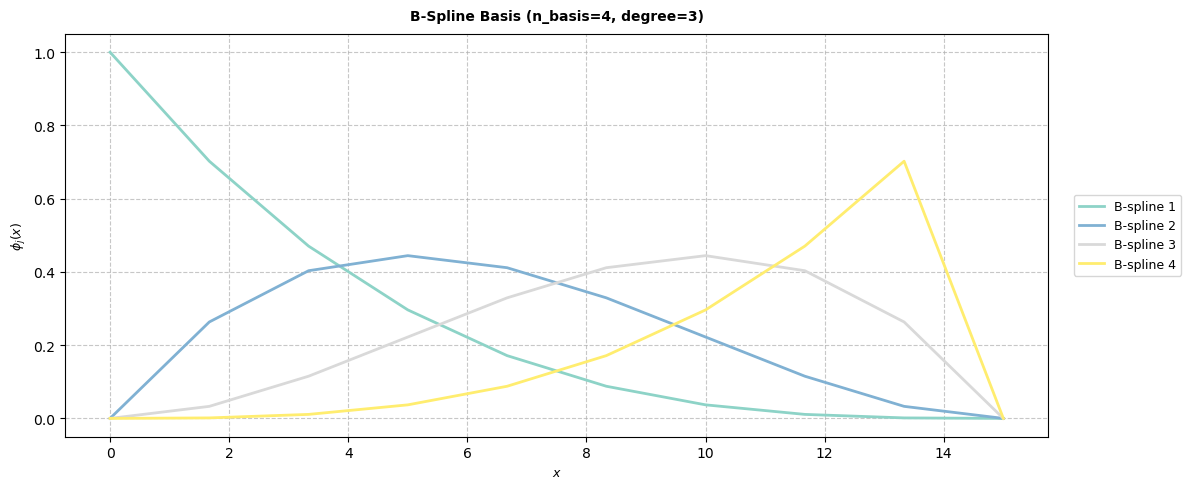


WEIGHT TYPE: TRIGONOMETRIC
----------------------------------------------------------------------------------------------------


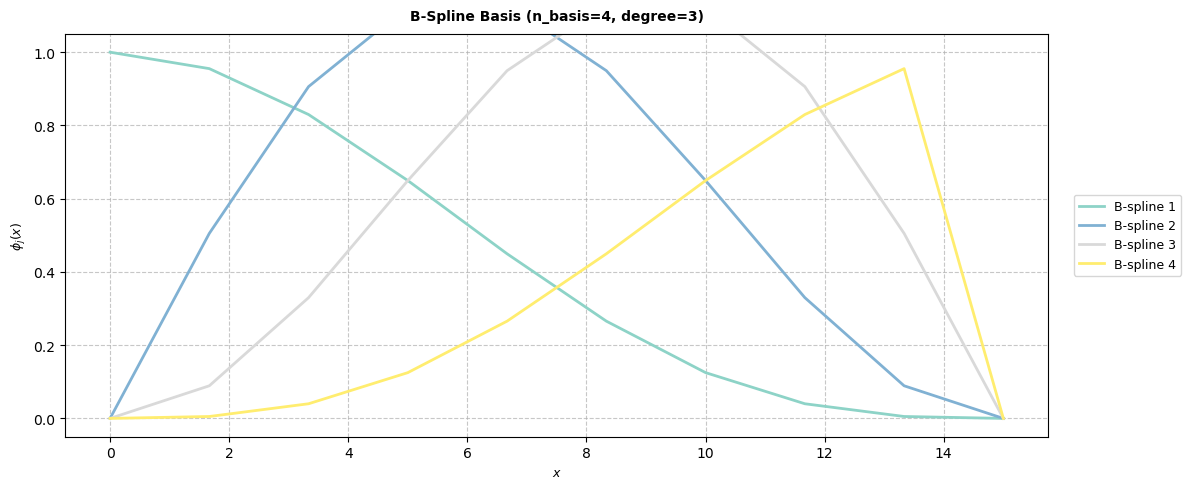


WEIGHT TYPE: HYPERBOLIC
----------------------------------------------------------------------------------------------------


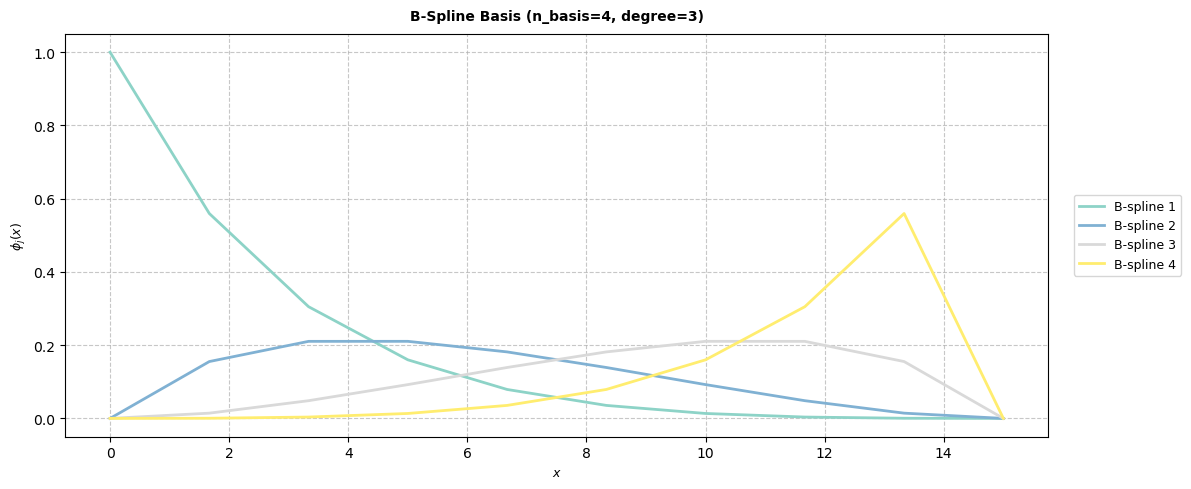


WEIGHT TYPE: VARIABLE_DEGREE
----------------------------------------------------------------------------------------------------


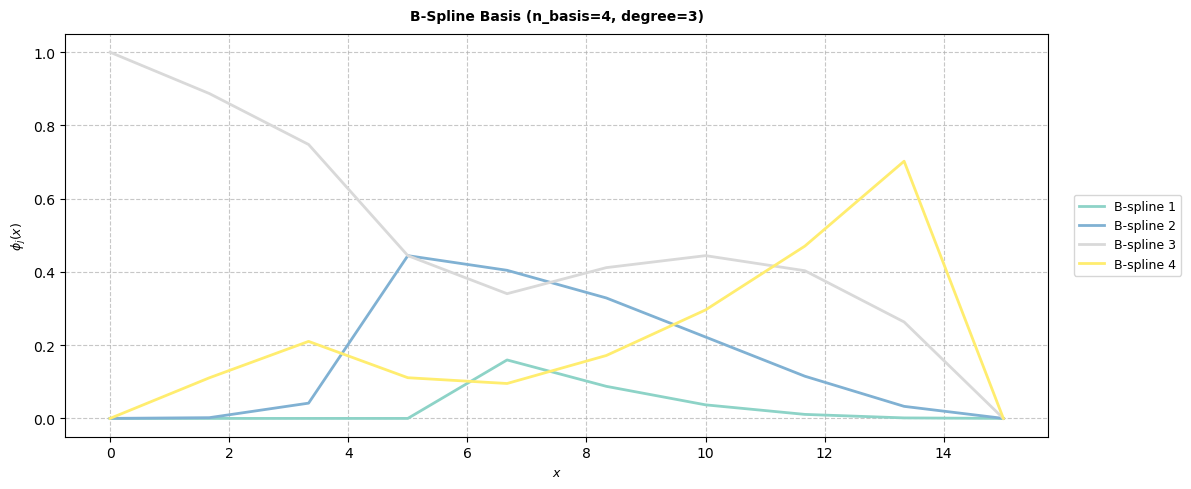


WEIGHT TYPE: NURBS
----------------------------------------------------------------------------------------------------


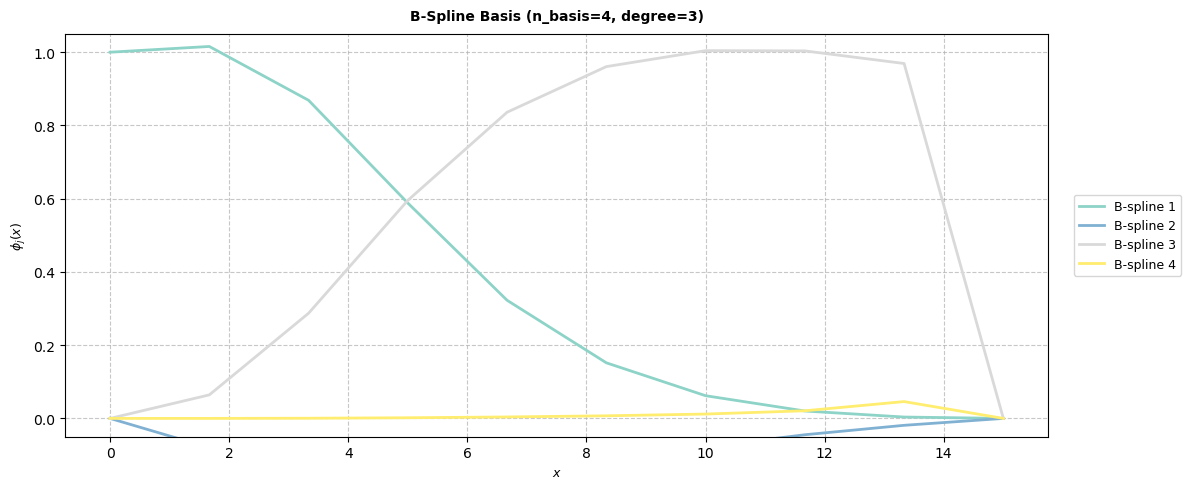

In [5]:

for weight_type in weight_type_list:

    print(f"\nWEIGHT TYPE: {weight_type.upper()}")
    print("-"*100)

    # 4. Initialize the basis class
    if weight_type == "variable_degree":
        p_func=smooth_sigmoid_degree_func
    else: 
        p_func=None
    basis = BSplineBasis(domain_range=domain, n_basis=n_basis, degree=degree, weight_type=weight_type, p_func=p_func, nurbs_weights=nurbs_weights)
    
    # 5. Create a plot of the B-splines
    basis.plot_b_spline(x_array)